# 04 — Entraînement & Évaluation du modèle (v2)

**Corrections vs v1 :**
- Suppression automatique des features à variance nulle (inutiles avec données d'une seule journée)
- Baseline intelligente : médiane par route × heure
- XGBoost : `reg:pseudohubererror` + `min_child_weight=50` + prédictions clippées à [0, 3600]
- Sauvegarde du `route_encoder` et des `active_features` pour l'API

**Ce qu'on fait ici :**
1. Charger le dataset Parquet
2. Supprimer les features à variance nulle
3. Split chronologique
4. Baseline naïve + baseline intelligente (route × heure)
5. Entraîner XGBoost avec validation croisée temporelle
6. Analyser les feature importances
7. Erreurs par ligne de bus
8. Sauvegarder modèle + artifacts pour l'API

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

from src.models.features import FEATURE_COLUMNS, TARGET_COLUMN, load_feature_dataset

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

DATASET_PATH = '../data/features/dataset.parquet'
MODEL_PATH   = '../data/features/model.pkl'

print('Setup OK')

Setup OK


## 1. Charger le dataset

In [2]:
X, y = load_feature_dataset(DATASET_PATH)
df   = pd.read_parquet(DATASET_PATH)

print(f"Lignes    : {len(X):,}")
print(f"Features  : {FEATURE_COLUMNS}")
print(f"Target    : mean={y.mean():.1f}s | median={y.median():.1f}s | std={y.std():.1f}s")
X.head()

Lignes    : 53,614,858
Features  : ['route_id_encoded', 'hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation']
Target    : mean=45.0s | median=0.0s | std=150.8s


,route_id_encoded,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation
0,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
1,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
2,171,8.00,4.00,14.00,1,0.60,0.00,17.00,0
3,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
4,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0


## 2. Nettoyage des features

Avec une seule journée de données, certaines features ont une variance nulle et n'apportent rien au modèle
(ex: `day_of_week`, `week_of_year`, `precipitation_mm`). On les détecte et supprime automatiquement.
Elles redeviendront utiles une fois la collecte multi-jours active.

In [3]:
zero_var_cols = [c for c in FEATURE_COLUMNS if X[c].std() < 1e-6]
ACTIVE_FEATURES = [c for c in FEATURE_COLUMNS if c not in zero_var_cols]

if zero_var_cols:
    print(f"⚠  Features supprimées (variance nulle) : {zero_var_cols}")
    print(f"   → Redeviendront utiles avec la collecte multi-jours.")
else:
    print("Toutes les features ont une variance non nulle ✓")

X = X[ACTIVE_FEATURES]
print(f"\n✓  Features actives ({len(ACTIVE_FEATURES)}) : {ACTIVE_FEATURES}")

⚠  Features supprimées (variance nulle) : ['day_of_week', 'week_of_year', 'precipitation_mm', 'is_precipitation']
   → Redeviendront utiles avec la collecte multi-jours.

✓  Features actives (5) : ['route_id_encoded', 'hour_of_day', 'is_rush_hour', 'temperature_c', 'wind_speed_kmh']


## 3. Split chronologique

On coupe les 20% dernières lignes comme jeu de test final — **jamais de shuffle** sur une série temporelle.

In [4]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {len(X_train):,} lignes")
print(f"Test  : {len(X_test):,} lignes")

Train : 42,891,886 lignes
Test  : 10,722,972 lignes


## 4. Baselines

Deux baselines :
- **Naïve** : toujours prédire la médiane globale du train set
- **Intelligente** : médiane par `route_id × hour_of_day` — c'est la vraie barre à battre

In [5]:
# Baseline naïve
baseline_val  = y_train.median()
baseline_pred = np.full(len(y_test), baseline_val)
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline naïve (médiane = {baseline_val:.1f}s)")
print(f"  MAE  : {baseline_mae:.1f}s")
print(f"  RMSE : {baseline_rmse:.1f}s")

# Baseline intelligente : médiane par route × heure (lookup via merge)
_lookup = df.iloc[:split_idx][['route_id_encoded', 'hour_of_day', 'delay_seconds']].copy()
route_hour_med = (
    _lookup
    .groupby(['route_id_encoded', 'hour_of_day'])['delay_seconds']
    .median()
    .reset_index()
    .rename(columns={'delay_seconds': 'pred_smart'})
)
_test_key = df.iloc[split_idx:][['route_id_encoded', 'hour_of_day']].copy().reset_index(drop=True)
_test_key = _test_key.merge(route_hour_med, on=['route_id_encoded', 'hour_of_day'], how='left')
_test_key['pred_smart'] = _test_key['pred_smart'].fillna(baseline_val)

smart_mae  = mean_absolute_error(y_test.values, _test_key['pred_smart'].values)
smart_rmse = np.sqrt(mean_squared_error(y_test.values, _test_key['pred_smart'].values))

print(f"\nBaseline intelligente (médiane route×heure)")
print(f"  MAE  : {smart_mae:.1f}s  ← objectif à battre")
print(f"  RMSE : {smart_rmse:.1f}s")

Baseline naïve (médiane = 0.0s)
  MAE  : 43.8s
  RMSE : 153.6s

Baseline intelligente (médiane route×heure)
  MAE  : 44.1s  ← objectif à battre
  RMSE : 149.7s


## 5. XGBoost — validation croisée temporelle

`TimeSeriesSplit` garantit que le modèle ne voit jamais de données "du futur".

Corrections v2 :
- `reg:pseudohubererror` : robuste aux outliers de délai (quelques bus très en retard)
- `min_child_weight=50` : évite d'overfitter sur peu de données temporelles
- Prédictions clippées à [0, 3600] (pas de retard négatif ou > 1h)

In [6]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:pseudohubererror',
    min_child_weight=50,
    random_state=42,
    n_jobs=-1,
)

cv_maes = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    model.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    pred_val = np.clip(model.predict(Xval), 0, 3600)
    mae = mean_absolute_error(yval, pred_val)
    cv_maes.append(mae)
    print(f"  Fold {fold+1}/{N_SPLITS} — MAE: {mae:.1f}s")

print(f"\nCV MAE moyen         : {np.mean(cv_maes):.1f}s ± {np.std(cv_maes):.1f}s")
print(f"Baseline naïve       : {baseline_mae:.1f}s")
print(f"Baseline route×heure : {smart_mae:.1f}s")

  Fold 1/5 — MAE: 97.6s
  Fold 2/5 — MAE: 95.8s
  Fold 3/5 — MAE: 99.5s
  Fold 4/5 — MAE: 131.6s
  Fold 5/5 — MAE: 106.1s

CV MAE moyen         : 106.1s ± 13.2s
Baseline naïve       : 43.8s
Baseline route×heure : 44.1s


In [7]:
# Entraînement final sur tout le train set
model.fit(X_train, y_train, verbose=False)

test_pred = np.clip(model.predict(X_test), 0, 3600)
test_mae  = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"=== Résultats sur le test set ===")
print(f"XGBoost MAE          : {test_mae:.1f}s")
print(f"XGBoost RMSE         : {test_rmse:.1f}s")
print(f"Baseline naïve MAE   : {baseline_mae:.1f}s")
print(f"Baseline route×heure : {smart_mae:.1f}s")
amelioration = (smart_mae - test_mae) / smart_mae * 100
print(f"Amélioration vs route×heure : {amelioration:.1f}%")

=== Résultats sur le test set ===
XGBoost MAE          : 97.9s
XGBoost RMSE         : 163.3s
Baseline naïve MAE   : 43.8s
Baseline route×heure : 44.1s
Amélioration vs route×heure : -122.0%


## 6. Feature importances

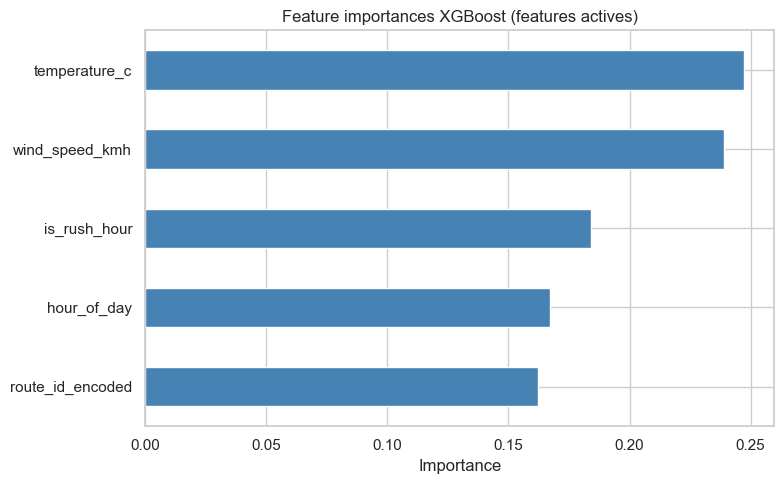

temperature_c      0.25
wind_speed_kmh     0.24
is_rush_hour       0.18
hour_of_day        0.17
route_id_encoded   0.16
dtype: float32


In [8]:
importances = pd.Series(model.feature_importances_, index=ACTIVE_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature importances XGBoost (features actives)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 7. Erreurs par ligne de bus

Quelles lignes sont les plus difficiles à prédire ?

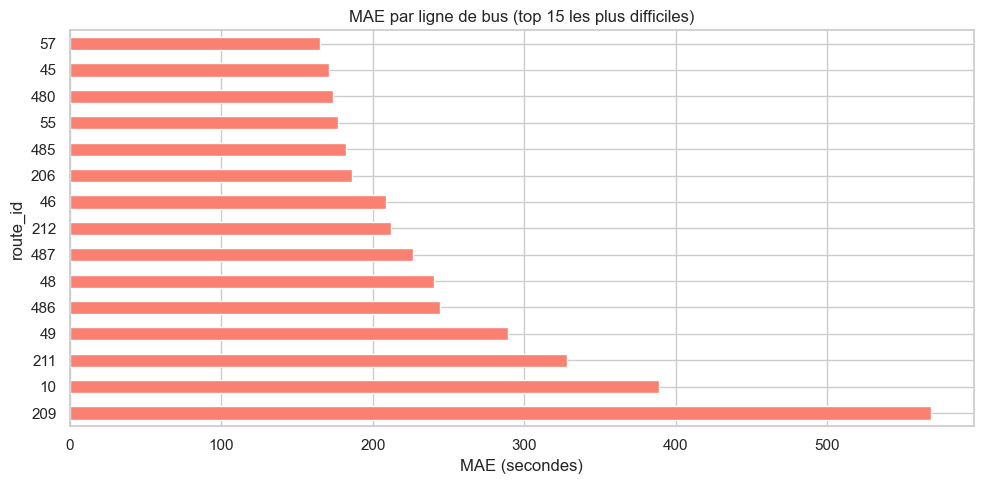

            mae       n
route_id               
209      568.29   65128
10       388.71   43095
211      328.40  114233
49       289.49  249564
486      244.18   10127
48       240.17  193534
487      226.34   24581
212      211.97   15061
46       208.62    8359
206      186.04   35157
485      182.04   46497
55       177.28  155783
480      173.59   27051
45       171.26   86404
57       165.32   29735


In [14]:
df_test = df.iloc[split_idx:].copy()
df_test['pred']  = test_pred
df_test['error'] = abs(df_test['delay_seconds'] - df_test['pred'])

route_map = df[['route_id_encoded', 'route_id']].drop_duplicates().set_index('route_id_encoded')['route_id']
df_test['route_id'] = df_test['route_id_encoded'].map(route_map)

by_route = (
    df_test.groupby('route_id')
    .agg(mae=('error', 'mean'), n=('error', 'count'))
    .query('n > 50')
    .sort_values('mae', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
by_route['mae'].plot.barh(ax=ax, color='salmon')
ax.set_title('MAE par ligne de bus (top 15 les plus difficiles)')
ax.set_xlabel('MAE (secondes)')
plt.tight_layout()
plt.show()
print(by_route)

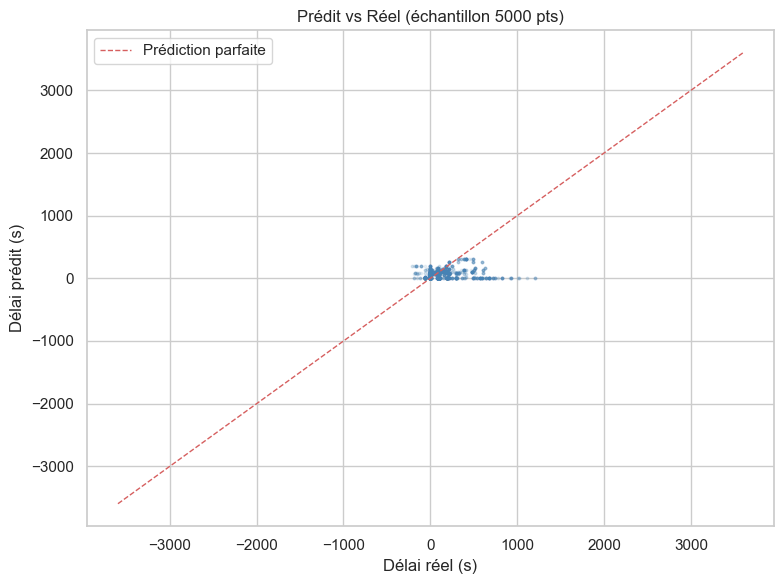

In [10]:
# Prédictions vs réalité
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test[:5000], test_pred[:5000], alpha=0.1, s=3, color='steelblue')
lim = max(abs(y_test.min()), y_test.max())
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, label='Prédiction parfaite')
ax.set_xlabel('Délai réel (s)')
ax.set_ylabel('Délai prédit (s)')
ax.set_title('Prédit vs Réel (échantillon 5000 pts)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sauvegarde du modèle et des artifacts

In [15]:
import json
from pathlib import Path
from datetime import datetime

run = {
    "run_name":        "xgboost-v2-single-day",
    "timestamp":       datetime.now().isoformat(),
    "params": {
        "n_estimators": 400, "max_depth": 6,
        "learning_rate": 0.05, "subsample": 0.8,
        "colsample_bytree": 0.8, "objective": "reg:pseudohubererror",
        "min_child_weight": 50, "n_splits": N_SPLITS, "n_rows": len(X),
    },
    "features_dropped": zero_var_cols,
    "features_used":    ACTIVE_FEATURES,
    "metrics": {
        "test_mae":           round(test_mae, 2),
        "test_rmse":          round(test_rmse, 2),
        "cv_mae_mean":        round(float(np.mean(cv_maes)), 2),
        "baseline_naive_mae": round(baseline_mae, 2),
        "baseline_smart_mae": round(smart_mae, 2),
    },
    "feature_importances": {
        feat: round(float(imp), 4)
        for feat, imp in sorted(zip(ACTIVE_FEATURES, model.feature_importances_), key=lambda x: -x[1])
    }
}

log_path = Path('../data/features/run_log.json')
log_path.parent.mkdir(parents=True, exist_ok=True)
log_path.write_text(json.dumps(run, indent=2))
print("Run log sauvegardé ✓")
print(json.dumps(run["metrics"], indent=2))

Run log sauvegardé ✓
{
  "test_mae": 97.89,
  "test_rmse": 163.3,
  "cv_mae_mean": 106.12,
  "baseline_naive_mae": 43.84,
  "baseline_smart_mae": 44.09
}


In [16]:
# Encodeur route_id + features actives + lookup route×heure → utilisés par l'API FastAPI
route_encoder = (
    df[['route_id', 'route_id_encoded']]
    .drop_duplicates()
    .set_index('route_id')['route_id_encoded']
    .to_dict()
)
route_encoder = {str(k): int(v) for k, v in route_encoder.items()}

# Lookup route×heure sur le dataset complet (toutes les données disponibles)
_full = df[['route_id', 'hour_of_day', 'delay_seconds']].copy()
_agg  = (
    _full
    .groupby(['route_id', 'hour_of_day'])['delay_seconds']
    .agg(median='median', mean='mean', count='count')
    .reset_index()
)
lookup_dict: dict = {}
for _, row in _agg.iterrows():
    rid = str(row['route_id'])
    hr  = str(int(row['hour_of_day']))
    lookup_dict.setdefault(rid, {})[hr] = {
        "median": round(float(row['median']), 1),
        "mean":   round(float(row['mean']), 1),
        "n":      int(row['count']),
    }

artifacts = {
    "active_features":   ACTIVE_FEATURES,
    "route_encoder":     route_encoder,
    "route_hour_lookup": lookup_dict,
    "global_median":     float(df['delay_seconds'].median()),
    "model_version":     "xgboost-v2-single-day",
}

artifacts_path = Path('../data/features/model_artifacts.json')
artifacts_path.write_text(json.dumps(artifacts, indent=2))
print(f"Artifacts sauvegardes")
print(f"  Features actives : {ACTIVE_FEATURES}")
print(f"  Routes encodees  : {len(route_encoder)} lignes")
print(f"  Lookup : {sum(len(v) for v in lookup_dict.values())} entrees")

Artifacts sauvegardes
  Features actives : ['route_id_encoded', 'hour_of_day', 'is_rush_hour', 'temperature_c', 'wind_speed_kmh']
  Routes encodees  : 185 lignes
  Lookup : 2157 entrees


In [13]:
Path(MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Modèle sauvegardé → {MODEL_PATH}")

Modèle sauvegardé → ../data/features/model.pkl


## 9. Prochaines étapes

- [x] Modèle entraîné et sauvegardé dans `data/features/model.pkl`
- [x] Artifacts sauvegardés dans `data/features/model_artifacts.json`
- [x] Run loggé dans `data/features/run_log.json`
- [ ] Lancer l'API : `uvicorn src.api.main:app --reload --port 8000`
- [ ] Tester `/predict` sur http://localhost:8000/docs

> **Quand la collecte multi-jours sera active**, re-générer le Parquet (notebook 03) puis re-run ce notebook :
> `day_of_week`, `week_of_year`, `precipitation_mm` et `is_precipitation` redeviendront automatiquement actifs.